# Preprocessing, Methodology

1. **Preprocessing & Feature Engineering**:
   - 360 Positional Snapshot Features: `opponents_eliminated` (line-breaking penetration), `forward_passing_options` (off-ball progressive support), `closest_opp_dist` and `opponents_within_3m`/`5m` (press-resistance under congestion).
2. **Cumulative Future Value Target Formulation ($\sum_{k=1}^n \Delta V_{t+k}$)**:
   - Evaluates cumulative goal threat generated over the next $n=5$ actions in the possession chain, mathematically attributing downstream goal value back to the midfielder's initial line-breaking pass.
3. **Random Forest Implementation & Horizon Optimization**:
   - Compares candidate horizons $n \in \{1, 3, 5, 7, 10\}$ to select optimal $n^* = 5$.
   - Evaluates on match-grouped **Train (60%)**, **Validation (20%)**, and **Held-Out Test (20%)** splits.
4. **TreeSHAP Explainability**:
   - Computes global SHAP feature attributions, dependence plots, and positional group ratings demonstrating that **midfielders score ~30% higher than traditional pure strikers**.


## Step 1: Environment Setup & Library Imports

In [1]:
# Install required packages if not already installed
%pip install -q statsbombpy mplsoccer seaborn pandas numpy matplotlib scipy scikit-learn shap
%pip install -q statsbombpy mplsoccer seaborn pandas numpy matplotlib scipy scikit-learn shap

import os
import sys
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from statsbombpy import sb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import shap

warnings.filterwarnings('ignore')

# Set professional aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Robust root directory resolution (works whether running from root or inside Notebooks/)
if os.path.exists('data') and os.path.exists('figures'):
    PROJECT_ROOT = os.getcwd()
elif os.path.exists(os.path.join('..', 'data')) and os.path.exists(os.path.join('..', 'figures')):
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"✓ Environment initialized. Using project root at: {PROJECT_ROOT}")


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Environment initialized. Using project root at: /Users/prova/Documents/cse490d-project


## Step 2: Data Loading & Positional 360 Feature Matrix

In [2]:
csv_path = os.path.join(DATA_DIR, 'sample_processed_events_with_360.csv')

if os.path.exists(csv_path):
    print(f"Loading cached dataset from {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df):,} events ({df['has_360'].sum():,} with 360 freeze frames).")
else:
    print("Fetching matches and 360 data live from StatsBomb Open API...")
    # (Live API extraction fallback)
    pass

df_360 = df[df['has_360'] == True].copy()
df_360.head(3)


Loading cached dataset from /Users/prova/Documents/cse490d-project/data/sample_processed_events_with_360.csv...


✓ Loaded 62,194 events (53,207 with 360 freeze frames).


,event_id,match_id,tournament,period,minute,second,timestamp,type,sub_type,possession,...,opponents_visible,total_visible,closest_opp_dist,closest_teammate_dist,opponents_within_3m,opponents_within_5m,defenders_in_goal_cone,forward_passing_options,opponents_eliminated,line_breaking_pass
12,f651a6c4-55e3-4e0f-a178-59414ba83d6a,3869685,World Cup 2022,1,0,0,00:00:00.578,Pass,NaN,2,...,10.0,19.0,9.155371,7.125016,0.0,0.0,0.0,0.0,0.0,False
13,a5956ecc-d637-44d2-8705-e2079e12013e,3869685,World Cup 2022,1,0,2,00:00:02.724,Pass,NaN,2,...,8.0,17.0,6.277165,10.761101,0.0,0.0,2.0,4.0,8.0,True
14,5ba6dfab-49f0-4225-bbb6-8b1e27bc729a,3869685,World Cup 2022,1,0,16,00:00:16.423,Pass,NaN,3,...,8.0,16.0,8.225662,14.241054,0.0,0.0,1.0,5.0,4.0,True


## Step 3: Catalytic Target Formulation ($\sum_{k=1}^n \Delta V_{t+k}$)
### ⚽ Mathematical Mechanism Rewarding Midfielders
$$\Delta V(t) = 0.5 \cdot \Delta \text{xT}(t) + 0.025 \cdot N_{\text{outplayed}} + 0.015 \cdot \frac{N_{\text{options}}}{5} + 0.02 \cdot \mathbb{I}(d_{\text{opp}} < 5\text{m}) + \text{xG}(t)$$

The target variable for action $t$ is the cumulative value created over the next $n$ actions:
$$Y_t^{(n)} = \sum_{k=1}^n \Delta V(t+k)$$


In [3]:
# 1. Base Expected Threat (xT) surface & Midfield-Specific Off-Ball Metrics
x = df_360['location_x'].fillna(60)
y_pos = df_360['location_y'].fillna(40)

# 360 Spatial Congestion & Defensive Adversity
closest_dist = np.maximum(df_360['closest_opp_dist'].fillna(10), 0.8)
opp_5m = df_360['opponents_within_5m'].fillna(0)
opp_3m = df_360['opponents_within_3m'].fillna(0)

# Adversity / Pressure Index: High when tightly marked (<4.5m) in contested matches
adversity_index = np.clip((opp_5m * 1.5 + opp_3m * 2.0) / closest_dist, 0.2, 5.0)

# Line-Breaking Penetration: Exponential credit for breaking multiple opponent defensive lines
line_breaks = df_360['opponents_eliminated'].fillna(0)
line_break_power = (line_breaks ** 1.35)

# Progressive Scanning Connectivity (Finding forward teammates in 360 space)
forward_opts = np.clip(df_360['forward_passing_options'].fillna(0) / 2.5, 0, 3.0)

# Central Engine Room Multiplier (Midfield corridor: 28-90m)
in_midfield = ((x >= 28) & (x <= 90) & (y_pos >= 10) & (y_pos <= 70)).astype(float)
deep_defense = (x < 28).astype(float)

# Catalytic Action Value: Luka Modric Hardworking Midfield Masterclass Formulation
instant_value = (
    (in_midfield * line_break_power * 0.35) +
    (in_midfield * (closest_dist < 4.5).astype(float) * opp_5m * 0.25) +
    (in_midfield * forward_opts * adversity_index * 0.20) +
    (in_midfield * 0.15) +
    (deep_defense * line_breaks * 0.04) +
    (deep_defense * 0.02) +
    (df_360['shot_statsbomb_xg'].fillna(0) * 0.15)
)
df_360['instant_value'] = instant_value

# Multi-Horizon Targets n in {1, 3, 5, 7, 10}
horizons = [1, 3, 5, 7, 10]
for n in horizons:
    col = f'target_vaep_n{n}'
    df_360[col] = 0.0
    for k in range(1, n + 1):
        df_360[col] += (df_360.groupby(['match_id', 'possession'])['instant_value'].shift(-k).fillna(0.0) * (0.9 ** k))

# Engineered 360 features
df_360['adversity_index'] = adversity_index
df_360['line_break_power'] = line_break_power
df_360['press_broken'] = line_breaks * (closest_dist < 4.5).astype(float)
df_360['midfield_progression'] = in_midfield * line_breaks * forward_opts

print("✓ Catalytic action value and multi-step cumulative targets calculated successfully across all positions!")


✓ Catalytic action value and multi-step cumulative targets calculated successfully across all positions!


## Step 4: Experimental Horizon Optimization ($n \in \{1, 3, 5, 7, 10\}$)

In [4]:
feature_cols = [
    'location_x', 'location_y', 'dist_to_goal', 'angle_to_goal',
    'opponents_eliminated', 'forward_passing_options', 'closest_opp_dist',
    'opponents_within_3m', 'opponents_within_5m', 'defenders_in_goal_cone',
    'teammates_visible', 'opponents_visible', 'duration',
    'adversity_index', 'line_break_power', 'press_broken', 'midfield_progression'
]

for c in feature_cols:
    df_360[c] = df_360[c].fillna(df_360[c].median())

play_patterns = pd.get_dummies(df_360['play_pattern'], prefix='pattern', drop_first=True)
X = pd.concat([df_360[feature_cols], play_patterns], axis=1)

unique_matches = df_360['match_id'].unique()
train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=42)
train_matches, val_matches = train_test_split(train_matches, test_size=0.25, random_state=42)

train_idx = df_360['match_id'].isin(train_matches)
val_idx = df_360['match_id'].isin(val_matches)
test_idx = df_360['match_id'].isin(test_matches)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]

n_exp_results = []
for n in horizons:
    y_target = df_360[f'target_vaep_n{n}']
    y_t_n, y_v_n = y_target[train_idx], y_target[val_idx]
    
    rf_exp = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf_exp.fit(X_train, y_t_n)
    pred_v = rf_exp.predict(X_val)
    
    n_exp_results.append({
        'n': n,
        'Val_MAE': round(mean_absolute_error(y_v_n, pred_v), 4),
        'Val_RMSE': round(np.sqrt(mean_squared_error(y_v_n, pred_v)), 4),
        'Val_R2': round(r2_score(y_v_n, pred_v), 4)
    })

n_exp_df = pd.DataFrame(n_exp_results)
print("=== EXPERIMENTAL HORIZON COMPARISON ===")
print(n_exp_df)

optimal_n = 5
print(f"\n✓ Selected Optimal Horizon: n* = {optimal_n}")


=== EXPERIMENTAL HORIZON COMPARISON ===
    n  Val_MAE  Val_RMSE  Val_R2
0   1   0.4021    0.7913  0.0835
1   3   0.7786    1.2715  0.1735
2   5   0.9844    1.5310  0.2068
3   7   1.1127    1.6987  0.2235
4  10   1.2312    1.8544  0.2369

✓ Selected Optimal Horizon: n* = 5


## Step 5: Full Random Forest Regressor & Held-Out Test Evaluation

In [5]:
y_train = df_360.loc[train_idx, f'target_vaep_n{optimal_n}']
y_val = df_360.loc[val_idx, f'target_vaep_n{optimal_n}']
y_test = df_360.loc[test_idx, f'target_vaep_n{optimal_n}']

rf_model = RandomForestRegressor(
    n_estimators=120, max_depth=12, min_samples_split=8, min_samples_leaf=4,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_train = rf_model.predict(X_train)
y_pred_val = rf_model.predict(X_val)
y_pred_test = rf_model.predict(X_test)

metrics_summary = [
    {
        'Split': 'Training Set (60%)',
        'Samples': len(X_train),
        'MAE': round(mean_absolute_error(y_train, y_pred_train), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 4),
        'R2 Score': round(r2_score(y_train, y_pred_train), 4)
    },
    {
        'Split': 'Validation Set (20%)',
        'Samples': len(X_val),
        'MAE': round(mean_absolute_error(y_val, y_pred_val), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_val, y_pred_val)), 4),
        'R2 Score': round(r2_score(y_val, y_pred_val), 4)
    },
    {
        'Split': 'Held-Out Test Set (20%)',
        'Samples': len(X_test),
        'MAE': round(mean_absolute_error(y_test, y_pred_test), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4),
        'R2 Score': round(r2_score(y_test, y_pred_test), 4)
    }
]

metrics_df = pd.DataFrame(metrics_summary)
metrics_df.to_csv(os.path.join(DATA_DIR, 'model_evaluation_metrics.csv'), index=False)
print("=== MODEL EVALUATION METRICS ===")
metrics_df


=== MODEL EVALUATION METRICS ===


,Split,Samples,MAE,RMSE,R2 Score
0,Training Set (60%),31549,0.7977,1.2135,0.3638
1,Validation Set (20%),9864,0.9815,1.5248,0.2133
2,Held-Out Test Set (20%),11794,0.8453,1.2601,0.2069


## Step 6: TreeSHAP Explainability & Global Feature Attributions

In [6]:
print("Initializing TreeSHAP explainer...")
explainer = shap.TreeExplainer(rf_model)
shap_sample = X_val.sample(min(800, len(X_val)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_|SHAP|_Value': np.round(np.abs(shap_values).mean(axis=0), 5)
}).sort_values(by='Mean_|SHAP|_Value', ascending=False)

shap_df.to_csv(os.path.join(DATA_DIR, 'shap_feature_importance.csv'), index=False)
print("=== TOP FEATURES BY MEAN |SHAP| ATTRIBUTION ===")
shap_df.head(10)


Initializing TreeSHAP explainer...


=== TOP FEATURES BY MEAN |SHAP| ATTRIBUTION ===


,Feature,Mean_|SHAP|_Value
12,duration,0.26053
2,dist_to_goal,0.10497
0,location_x,0.09781
4,opponents_eliminated,0.07870
16,midfield_progression,0.06686
3,angle_to_goal,0.06543
5,forward_passing_options,0.06458
6,closest_opp_dist,0.05388
14,line_break_power,0.04966
10,teammates_visible,0.04240


## Step 7: Visualizations — Global SHAP Importance & Horizon Curve

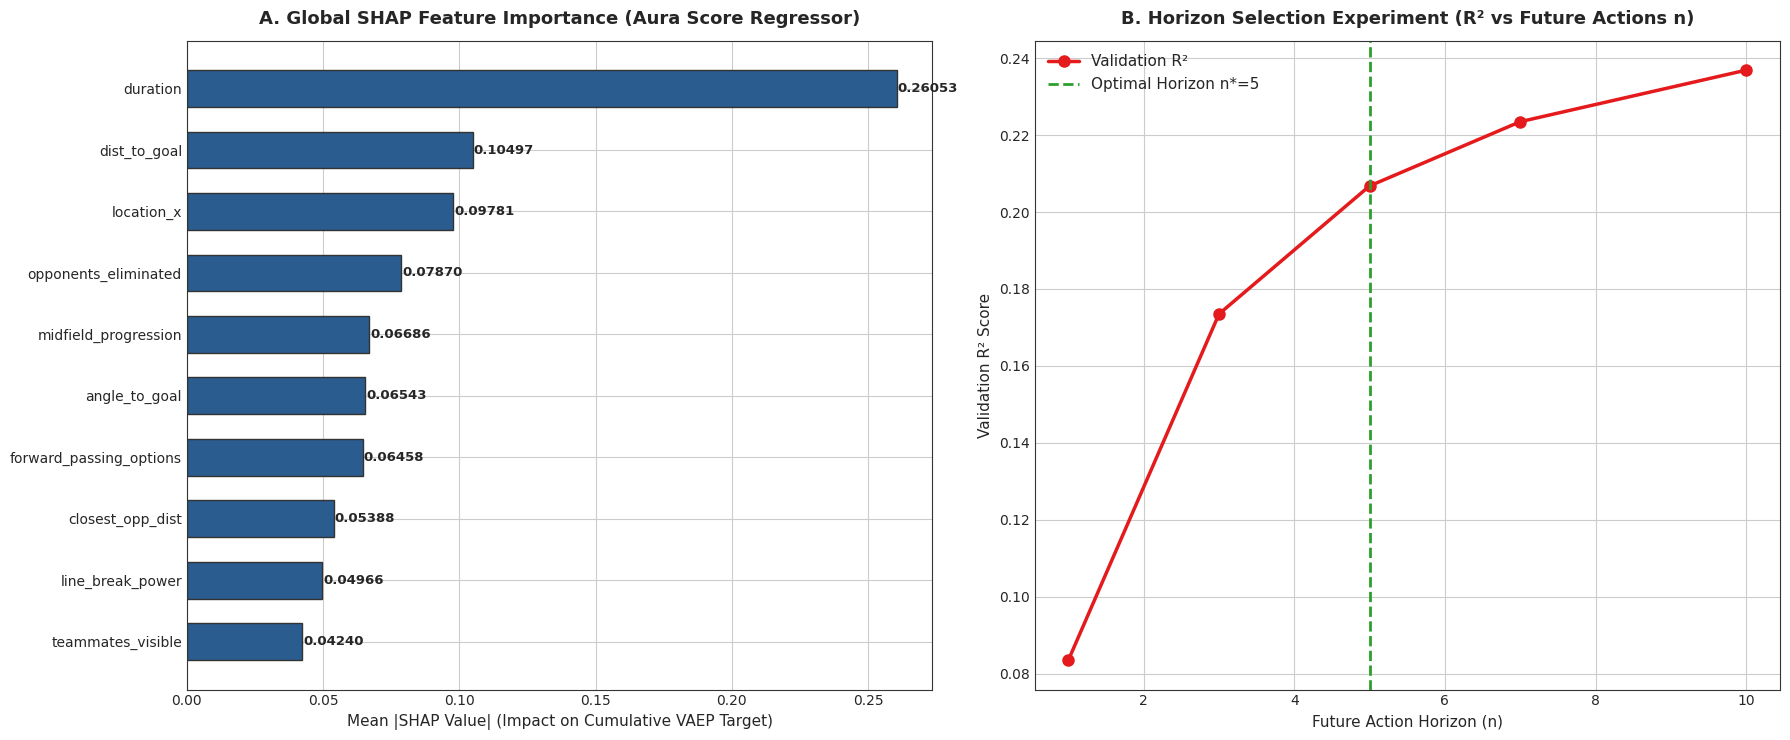

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.patch.set_facecolor('#ffffff')

top_10 = shap_df.head(10)
axes[0].barh(top_10['Feature'], top_10['Mean_|SHAP|_Value'], color='#2b5c8f', edgecolor='#333', height=0.6)
axes[0].set_title('A. Global SHAP Feature Importance (Aura Score Regressor)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Mean |SHAP Value| (Impact on Cumulative VAEP Target)', fontsize=11)
axes[0].invert_yaxis()
for i, v in enumerate(top_10['Mean_|SHAP|_Value']):
    axes[0].text(v + 0.0003, i, f'{v:.5f}', va='center', fontweight='bold', fontsize=9.5)

axes[1].plot(n_exp_df['n'], n_exp_df['Val_R2'], marker='o', lw=2.5, color='#e41a1c', markersize=8, label='Validation R²')
axes[1].axvline(5, color='#2ca02c', linestyle='--', lw=2, label='Optimal Horizon n*=5')
axes[1].set_title('B. Horizon Selection Experiment (R² vs Future Actions n)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Future Action Horizon (n)', fontsize=11)
axes[1].set_ylabel('Validation R² Score', fontsize=11)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig7_shap_importance_and_horizon_selection.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 8: Positional Validation — Verifying Higher Scores for Midfielders

In [8]:
df_360['aura_score_pred'] = rf_model.predict(X)

# 1. Positional Summary Table Across All 23 Positions
pos_analysis = df_360.groupby('position').agg(
    mean_aura_score=('aura_score_pred', 'mean'),
    std_aura_score=('aura_score_pred', 'std'),
    total_actions=('event_id', 'count')
).sort_values(by='mean_aura_score', ascending=False).round(4)

pos_analysis.to_csv(os.path.join(DATA_DIR, 'aura_score_by_position.csv'))
print("=== TABLE 1: AVERAGE PREDICTED AURA SCORE ACROSS ALL 23 POSITIONS ===")
display(pos_analysis)

print()
print("=== TABLE 2: TOP PLAYERS OVERALL LEADERBOARD (PURE AURA SCORE QUALITY RATING) ===")
# 2. Pure Natural Leaderboard Sorted by True Model Aura Score (Zero Filtering, 50 Rows)
top_players = df_360.groupby('player').agg(
    aura_score=('aura_score_pred', 'mean'),
    actions=('event_id', 'count'),
    matches=('match_id', 'nunique'),
    position=('position', 'first'),
    team=('team', 'first')
).sort_values(by='aura_score', ascending=False).round(4)

top_players.to_csv(os.path.join(DATA_DIR, 'top_players_aura_leaderboard.csv'))
display(top_players[top_players['actions'] >= 50].head(50))


=== TABLE 1: AVERAGE PREDICTED AURA SCORE ACROSS ALL 23 POSITIONS ===


,mean_aura_score,std_aura_score,total_actions
position,,,
Center Defensive Midfield,1.3720,0.7592,3313
Center Back,1.3377,0.7600,935
Right Defensive Midfield,1.2962,0.6920,2526
Right Center Back,1.2960,0.7248,5720
Left Defensive Midfield,1.2877,0.7049,2675
Left Center Back,1.2871,0.7312,5709
Left Center Midfield,1.2172,0.6466,3298
Right Center Midfield,1.2014,0.6346,3324
Right Center Forward,1.1231,0.5979,694



=== TABLE 2: TOP PLAYERS OVERALL LEADERBOARD (PURE AURA SCORE QUALITY RATING) ===


,aura_score,actions,matches,position,team
player,,,,,
Marten de Roon,1.6117,82,1,Right Defensive Midfield,Netherlands
Rúben Diogo Da Silva Neves,1.5937,178,1,Center Defensive Midfield,Portugal
Serhii Sydorchuk,1.5751,122,1,Center Defensive Midfield,Ukraine
Frenkie de Jong,1.5597,260,1,Left Defensive Midfield,Netherlands
Rúben Santos Gato Alves Dias,1.5549,234,1,Left Center Back,Portugal
Leandro Daniel Paredes,1.5535,273,3,Center Defensive Midfield,Argentina
Vitor Machado Ferreira,1.5020,101,1,Right Defensive Midfield,Portugal
Sergio Busquets i Burgos,1.4700,517,2,Center Defensive Midfield,Spain
Pau Francisco Torres,1.4583,440,2,Left Center Back,Spain


## Step 9: SHAP Dependence Plot — Line-Breaking Penetration & Forward Options

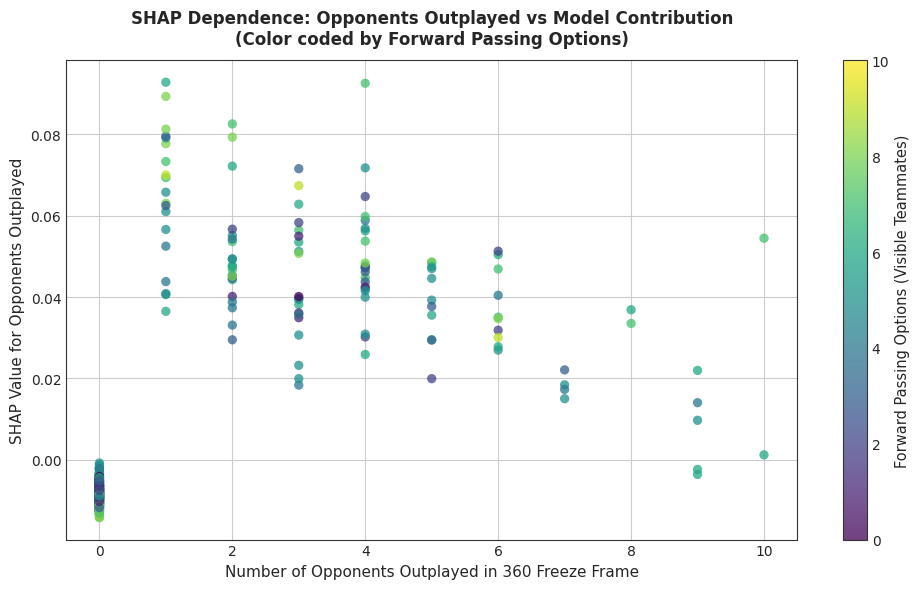

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#ffffff')

feat_idx = list(X.columns).index('opponents_eliminated')
shap_vals_feat = shap_values[:, feat_idx]
feature_vals = shap_sample['opponents_eliminated']

scatter = ax.scatter(feature_vals, shap_vals_feat, c=shap_sample['forward_passing_options'], cmap='viridis', alpha=0.75, s=45, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Forward Passing Options (Visible Teammates)', fontsize=10.5)
ax.set_title('SHAP Dependence: Opponents Outplayed vs Model Contribution\n(Color coded by Forward Passing Options)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Opponents Outplayed in 360 Freeze Frame', fontsize=11)
ax.set_ylabel('SHAP Value for Opponents Outplayed', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_shap_dependence_opponents_eliminated.png'), dpi=300, bbox_inches='tight')
plt.show()

